In [1]:
import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

I0000 00:00:1773293774.235334    8634 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773293774.239963    8634 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773293774.618673    8634 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773293776.056238    8634 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

In [2]:
# Garante reprodutibilidade
SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

tf.keras.utils.set_random_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

In [3]:
# Gera o domínio das funções
x = np.linspace(0, 5, 2000).reshape(-1, 1)

# a) f(x) = sin(2x) + cos(3x)
def function_a(x):
    return np.sin(2 * x) + np.cos(3 * x)

# b) f(x) = 10x^5 + 5x^4 + 2x^3 - 0.5x^2 + 3x + 2
def function_b(x):
    return 10*x**5 + 5*x**4 + 2*x**3 - 0.5*x**2 + 3*x + 2

# Cria vetores contendo os resultados de cada função aplicada no espaço amostral de x
y_a = function_a(x)
y_b = function_b(x)

In [4]:
def train_mlp(x, y):

    # Divide em treino e validação: 80% treino/20% validação
    x_train, x_val, y_train, y_val = train_test_split(
        x, y, test_size=0.2, random_state=42
    )

    # Normaliza
    scaler_x = MinMaxScaler()
    scaler_y = MinMaxScaler()

    x_train_scaled = scaler_x.fit_transform(x_train)
    y_train_scaled = scaler_y.fit_transform(y_train)

    x_val_scaled = scaler_x.transform(x_val)
    y_val_scaled = scaler_y.transform(y_val)

    # Early stopping
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=30,
        restore_best_weights=True
    )

    # Constrói o MLP
    model = Sequential([
        Dense(128, activation='relu', input_dim=1),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(1)
    ])

    model.compile(
        optimizer=Adam(learning_rate=0.005),
        loss='mse'
    )

    # Treina o modelo
    history = model.fit(
        x_train_scaled,
        y_train_scaled,
        validation_data=(x_val_scaled, y_val_scaled),
        epochs=300,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )

    return model, history, scaler_x, scaler_y

In [5]:
def plot_results(x, y, model, history, scaler_x, scaler_y, title):

    # Prevê os dados para o gráfico de aproximação
    x_scaled = scaler_x.transform(x)
    y_pred_scaled = model.predict(x_scaled, verbose=0)

    # Reverte a escala para os valores originais
    y_pred = scaler_y.inverse_transform(y_pred_scaled)

    # Plota os resultados
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: Função real vs aproximada
    ax1.plot(x, y, label='Função real')
    ax1.plot(x, y_pred, '--', label='Aproximação MLP')
    ax1.set_title(f"{title}")
    ax1.set_xlabel("x")
    ax1.set_ylabel("f(x)")
    ax1.legend()
    ax1.grid(True)

    # Gráfico 2: Curva de aprendizado
    ax2.plot(history.history['loss'], label="Erro treino")
    ax2.plot(history.history['val_loss'], label="Erro validação")
    ax2.set_title("Curva de Aprendizado")
    ax2.set_xlabel("Épocas")
    ax2.set_ylabel("Erro")
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

In [6]:
# Exporta resultados para csv
def export(x_data, y_real, model, history, scaler_x, scaler_y, file_prefix, max_rows=30):
    x_scaled = scaler_x.transform(x_data) if scaler_x else x_data
    y_pred_scaled = model.predict(x_scaled, verbose=0)
    y_pred = scaler_y.inverse_transform(y_pred_scaled) if scaler_y else y_pred_scaled

    df_function = pd.DataFrame({
        'X': np.squeeze(x_data),
        'Y_Real': np.squeeze(y_real),
        'Y_Predicted': np.squeeze(y_pred)
    })

    if len(df_function) > max_rows:
        step = len(df_function) // max_rows
        df_function = df_function.iloc[::step].copy()
        
    df_function.to_csv(f'{file_prefix}_approximation.csv', index=False)
    
    df_history = pd.DataFrame(history.history)
    df_history.index.name = 'Epoch'
    df_history.reset_index(inplace=True)

    if len(df_history) > max_rows:
        step = len(df_history) // max_rows
        df_history = df_history.iloc[::step].copy()
    
    df_history.to_csv(f'{file_prefix}_loss.csv', index=False)

/home/elias/miniconda3/envs/deep_learning/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773293776.505709    8634 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1773293776.506198    8725 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1773293776.522847    8634 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you w

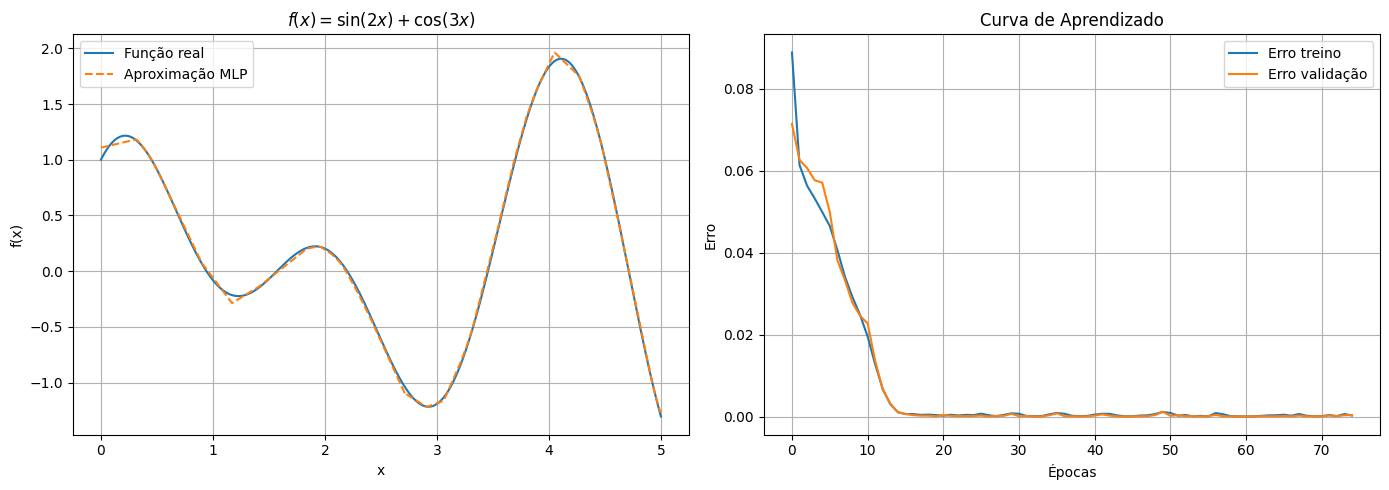

In [7]:
model, history, scaler_x, scaler_y = train_mlp(x, y_a)

plot_results(
    x,
    y_a,
    model,
    history,
    scaler_x,
    scaler_y,
    r"$f(x)=\sin(2x)+\cos(3x)$"
)

In [8]:
export(x, y_a, model, history, scaler_x, scaler_y, "function_a")

/home/elias/miniconda3/envs/deep_learning/lib/python3.11/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1773293791.587070    8634 node_def_util.cc:682] NodeDef mentions attribute use_unbounded_threadpool which is not in the op definition: Op<name=MapDataset; signature=input_dataset:variant, other_arguments: -> handle:variant; attr=f:func; attr=Targuments:list(type),min=0; attr=output_types:list(type),min=1; attr=output_shapes:list(shape),min=1; attr=use_inter_op_parallelism:bool,default=true; attr=preserve_cardinality:bool,default=false; attr=force_synchronous:bool,default=false; attr=metadata:string,default=""> This may be expected if your graph generating binary is newer  than this binary. Unknown attributes will be i

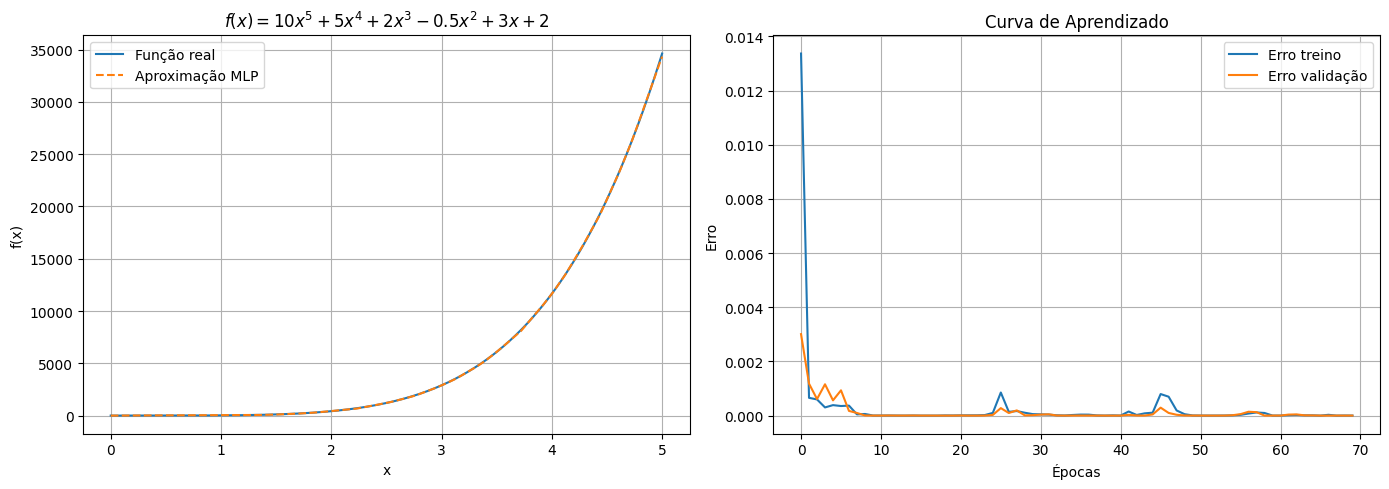

In [9]:
model, history, scaler_x, scaler_y = train_mlp(x, y_b)

plot_results(
    x,
    y_b,
    model,
    history,
    scaler_x,
    scaler_y,
    r"$f(x)=10x^{5}+5x^{4}+2x^{3}-0.5x^{2}+3x+2$"
)

In [10]:
export(x, y_b, model, history, scaler_x, scaler_y, "function_b")